# Notebook 03 — Estados latentes dinámicos sobre Dialog2Flow 2.0

En esta notebook se retoma la idea de los **estados latentes dinámicos** del diálogo, pero adaptada a la versión escalada del trabajo.

El objetivo es evaluar si las representaciones dinámicas aportan un comportamiento experimental interesante frente a los embeddings estáticos de turno.

La notebook se organiza en tres partes:

1. Construcción de estados dinámicos a partir de los embeddings estáticos.
2. Análisis de divergencia entre embedding estático y estado dinámico.
3. Benchmark ANN reducido para comparar representaciones estáticas y dinámicas.

La idea metodológica es simple: si los estados dinámicos muestran patrones claros y defendibles, entran en el informe/paper; si no, quedan como análisis exploratorio o trabajo futuro.

In [1]:
!pip install -q gdown faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 39.7 MB/s eta 0:00:00


## 1. Configuración del experimento

Seleccionamos el modelo de embeddings y algunos parámetros generales.

Para una primera corrida formal conviene comenzar con `all-MiniLM-L6-v2`, porque ya mostró buen rendimiento y ocupa menos memoria que MPNet.

In [2]:
# EMBEDDING_EXPERIMENTO = "all-mpnet-base-v2"
EMBEDDING_EXPERIMENTO = "all-MiniLM-L6-v2"

RANDOM_STATE = 42

# Cantidad de consultas para el benchmark ANN reducido.
N_QUERIES = 10000

# Vecinos máximos para evaluar Recall@1, Recall@10 y Recall@100.
K_MAX = 100

# Repeticiones de búsqueda para estabilizar QPS.
N_REPETICIONES_BUSQUEDA = 3

# Parámetros reducidos para no repetir toda la Notebook 02.
NPROBE_VALUES = [1, 4, 16, 64]
EFSEARCH_VALUES = [16, 64, 128, 256]

# Tamaño de muestra para gráficos exploratorios.
N_MUESTRA_ANALISIS = 100000

## 2. Archivos de entrada

Usamos los archivos generados en las notebooks anteriores:

- `dialogs-2.0.pkl`: dataframe con los turnos.
- `ids.npy`: identificadores de filas.
- `embeddings_minilm.npy` o `embeddings_mpnet.npy`: embeddings estáticos.

In [3]:
# Ids de Google Drive

id_ids = "1hWC7nLvSboFHyykjr7VFAEmcvz8re1cY"

id_embeddings_mpnet = "1ndtChhGE3U5bkJ59NvuXhbX5Bgr7uOGe"
id_embeddings_minilm = "1imF_9lIGgGRJ7KQm-KhRPyinDUqPI_fW"

id_dataset = "1kRbmvg3NB96pWMUl866GZRrT6Zq9vxcb"

## 3. Descarga y carga de datos

Los embeddings se cargan con `mmap_mode="r"` para evitar cargar todo el archivo en RAM desde el inicio.

In [4]:
import os
import gc
import time
import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss

if EMBEDDING_EXPERIMENTO == "all-MiniLM-L6-v2":
    id_embeddings = id_embeddings_minilm
    archivo_embeddings = "embeddings_minilm.npy"
    short_name = "minilm"

elif EMBEDDING_EXPERIMENTO == "all-mpnet-base-v2":
    id_embeddings = id_embeddings_mpnet
    archivo_embeddings = "embeddings_mpnet.npy"
    short_name = "mpnet"

archivos = {
    archivo_embeddings: id_embeddings,
    "ids.npy": id_ids,
    "dialogs-2.0.pkl": id_dataset,
}

for nombre_archivo, file_id in archivos.items():
    if not os.path.exists(nombre_archivo):
        print("Descargando:", nombre_archivo)
        gdown.download(f"https://drive.google.com/uc?id={file_id}", nombre_archivo, quiet=False)
    else:
        print("Ya existe:", nombre_archivo)

Descargando: embeddings_minilm.npy


Downloading...
From (original): https://drive.google.com/uc?id=1imF_9lIGgGRJ7KQm-KhRPyinDUqPI_fW
From (redirected): https://drive.google.com/uc?id=1imF_9lIGgGRJ7KQm-KhRPyinDUqPI_fW&confirm=t&uuid=4993b409-97ca-4f90-84ab-dfc80fd8dbf2
To: /content/embeddings_minilm.npy
100%|██████████| 1.54G/1.54G [00:24<00:00, 63.2MB/s]


Descargando: ids.npy


Downloading...
From: https://drive.google.com/uc?id=1hWC7nLvSboFHyykjr7VFAEmcvz8re1cY
To: /content/ids.npy
100%|██████████| 8.00M/8.00M [00:00<00:00, 82.9MB/s]


Descargando: dialogs-2.0.pkl


Downloading...
From (original): https://drive.google.com/uc?id=1kRbmvg3NB96pWMUl866GZRrT6Zq9vxcb
From (redirected): https://drive.google.com/uc?id=1kRbmvg3NB96pWMUl866GZRrT6Zq9vxcb&confirm=t&uuid=c90742de-68cb-4c94-93ad-2f1ca612ee1a
To: /content/dialogs-2.0.pkl
100%|██████████| 156M/156M [00:01<00:00, 135MB/s]


In [5]:
embeddings = np.load(archivo_embeddings, mmap_mode="r")
ids = np.load("ids.npy")
df = pd.read_pickle("dialogs-2.0.pkl")

print("Embeddings:", embeddings.shape, embeddings.dtype)
print("Ids:", ids.shape)
print("Dataset:", df.shape)

Embeddings: (1000023, 384) float32
Ids: (1000023,)
Dataset: (1000023, 11)
Validación correcta.


## 4. Construcción de estados latentes dinámicos

Construimos una representación dinámica por turno. Para cada diálogo, el estado se actualiza de manera acumulativa:

\[
h_t = LayerNorm(h_{t-1} + e_t)
\]

donde:

- \(e_t\) es el embedding estático del turno actual.
- \(h_{t-1}\) es el estado acumulado del diálogo hasta el turno anterior.
- \(h_t\) representa el estado dinámico del diálogo en el turno actual.

La escritura se hace sobre un archivo `.npy` usando `open_memmap`, para evitar mantener una segunda matriz completa en RAM.

In [6]:
import torch

def cosine_np(a, b, eps=1e-12):
    return float(np.dot(a, b) / ((np.linalg.norm(a) + eps) * (np.linalg.norm(b) + eps)))

In [7]:
archivo_dynamic = f"dynamic_embeddings_{short_name}.npy"
archivo_similitud = f"similitud_static_dynamic_{short_name}.npy"
archivo_turn_pos = f"turn_position_{short_name}.npy"

n, d = embeddings.shape

# LayerNorm se define una sola vez usando la dimensionalidad de los embeddings.
# Se usa en CPU porque la operación es simple y evita depender del entorno GPU.
layer_norm = torch.nn.LayerNorm(d, elementwise_affine=False)
layer_norm.eval()

if not os.path.exists(archivo_dynamic):
    dynamic_embeddings = np.lib.format.open_memmap(
        archivo_dynamic,
        mode="w+",
        dtype="float32",
        shape=(n, d)
    )

    similitud_static_dynamic = np.lib.format.open_memmap(
        archivo_similitud,
        mode="w+",
        dtype="float32",
        shape=(n,)
    )

    turn_position = np.lib.format.open_memmap(
        archivo_turn_pos,
        mode="w+",
        dtype="int32",
        shape=(n,)
    )

    t0 = time.time()
    cantidad_dialogos = 0

    with torch.no_grad():
        for dialogue_id, grupo in df.groupby("dialogue_id", sort=False):
            grupo = grupo.sort_values("turn_id")
            indices_dialogo = grupo.index.to_numpy()

            h = torch.zeros(d, dtype=torch.float32)

            for idx in indices_dialogo:
                e_np = np.asarray(embeddings[idx], dtype="float32")
                e = torch.from_numpy(e_np.copy())

                h = layer_norm(h + e)
                h_np = h.numpy().astype("float32", copy=False)

                dynamic_embeddings[idx] = h_np
                similitud_static_dynamic[idx] = cosine_np(e_np, h_np)
                turn_position[idx] = int(df.loc[idx, "turn_id"])

            cantidad_dialogos += 1

            if cantidad_dialogos % 10000 == 0:
                print("Diálogos procesados:", cantidad_dialogos)

    dynamic_embeddings.flush()
    similitud_static_dynamic.flush()
    turn_position.flush()

    print("Estados dinámicos generados en:", archivo_dynamic)
    print("Tiempo total:", round(time.time() - t0, 2), "segundos")

else:
    print("Ya existe el archivo:", archivo_dynamic)
    print("No se vuelve a generar.")


Diálogos procesados: 10000
Diálogos procesados: 20000
Diálogos procesados: 30000
Diálogos procesados: 40000
Diálogos procesados: 50000
Diálogos procesados: 60000
Diálogos procesados: 70000
Diálogos procesados: 80000
Diálogos procesados: 90000
Diálogos procesados: 100000
Estados dinámicos generados en: dynamic_embeddings_minilm.npy
Tiempo total: 152.72 segundos


In [8]:
dynamic_embeddings = np.load(archivo_dynamic, mmap_mode="r")
similitud_static_dynamic = np.load(archivo_similitud, mmap_mode="r")
turn_position = np.load(archivo_turn_pos, mmap_mode="r")

print("Dynamic embeddings:", dynamic_embeddings.shape, dynamic_embeddings.dtype)
print("Similitudes:", similitud_static_dynamic.shape)
print("Posiciones:", turn_position.shape)

Dynamic embeddings: (1000023, 384) float32
Similitudes: (1000023,)
Posiciones: (1000023,)


## 5. Análisis estático vs dinámico

Primero analizamos cuánto se aleja el estado dinámico del embedding estático del turno correspondiente.

Si el estado dinámico no se diferencia del embedding estático, entonces la representación acumulativa no estaría aportando demasiado.

Si se diferencia demasiado, podría estar perdiendo la semántica local del turno.

Lo interesante es observar si existe una divergencia progresiva y controlada.

In [9]:
np.random.seed(RANDOM_STATE)

muestra_size = min(N_MUESTRA_ANALISIS, len(similitud_static_dynamic))
muestra_idx = np.random.choice(len(similitud_static_dynamic), size=muestra_size, replace=False)

sim_muestra = np.asarray(similitud_static_dynamic[muestra_idx])
turn_muestra = np.asarray(turn_position[muestra_idx])

print("Similitud promedio:", sim_muestra.mean())
print("Similitud mediana:", np.median(sim_muestra))
print("Similitud mínima:", sim_muestra.min())
print("Similitud máxima:", sim_muestra.max())

Similitud promedio: 0.41192517
Similitud mediana: 0.3437574
Similitud mínima: -0.08196446
Similitud máxima: 1.0000002


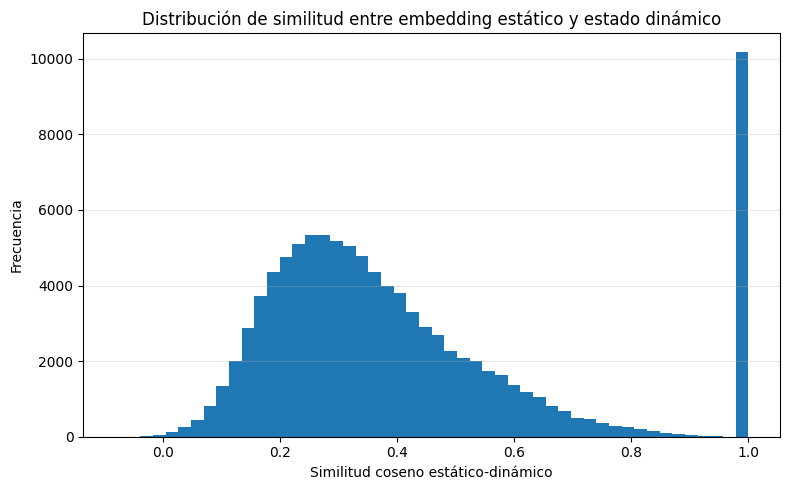

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(sim_muestra, bins=50)
plt.xlabel("Similitud coseno estático-dinámico")
plt.ylabel("Frecuencia")
plt.title("Distribución de similitud entre embedding estático y estado dinámico")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

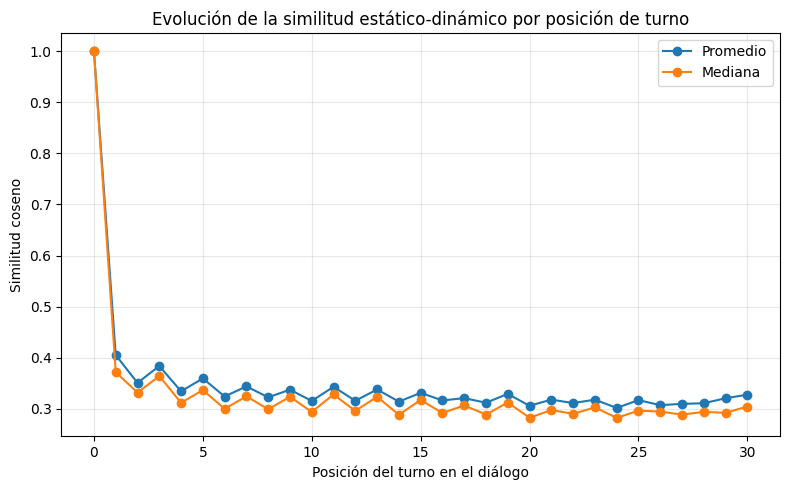

In [11]:
df_sim = pd.DataFrame({
    "turn_position": turn_muestra,
    "similarity": sim_muestra
})

df_turn = (
    df_sim[df_sim["turn_position"] <= 30]
    .groupby("turn_position", as_index=False)
    .agg(
        similarity_mean=("similarity", "mean"),
        similarity_median=("similarity", "median")
    )
)

plt.figure(figsize=(8, 5))
plt.plot(df_turn["turn_position"], df_turn["similarity_mean"], marker="o", label="Promedio")
plt.plot(df_turn["turn_position"], df_turn["similarity_median"], marker="o", label="Mediana")
plt.xlabel("Posición del turno en el diálogo")
plt.ylabel("Similitud coseno")
plt.title("Evolución de la similitud estático-dinámico por posición de turno")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Cantidad de diálogos graficados: 50


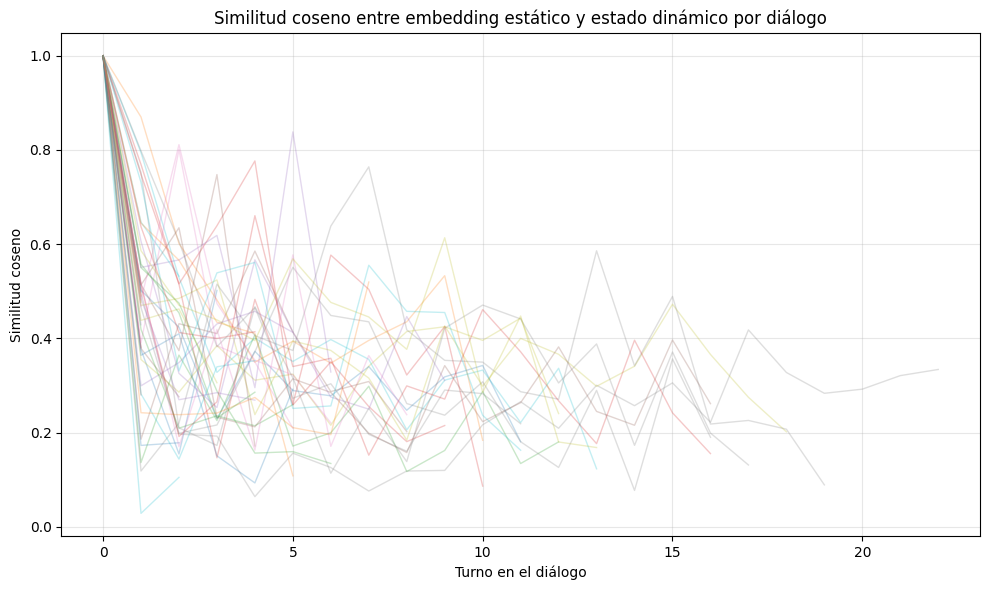

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cantidad de diálogos a graficar.
# Si es None, se grafican todos.
N_DIALOGOS_GRAFICO = 50
RANDOM_STATE_GRAFICO = 42

# Dataframe auxiliar con la información necesaria para graficar
df_plot = df[["dialogue_id", "turn_id"]].copy()
df_plot["cosine_similarity"] = np.asarray(similitud_static_dynamic)

# Selección de diálogos
dialogos_disponibles = df_plot["dialogue_id"].unique()

if N_DIALOGOS_GRAFICO is None or N_DIALOGOS_GRAFICO >= len(dialogos_disponibles):
    dialogos_muestra = dialogos_disponibles
else:
    np.random.seed(RANDOM_STATE_GRAFICO)
    dialogos_muestra = np.random.choice(
        dialogos_disponibles,
        size=N_DIALOGOS_GRAFICO,
        replace=False
    )

df_plot_muestra = df_plot[df_plot["dialogue_id"].isin(dialogos_muestra)]

print("Cantidad de diálogos graficados:", len(dialogos_muestra))

plt.figure(figsize=(10, 6))

for dialog_id, grupo in df_plot_muestra.groupby("dialogue_id"):
    grupo = grupo.sort_values("turn_id")
    plt.plot(
        grupo["turn_id"],
        grupo["cosine_similarity"],
        alpha=0.25,
        linewidth=1
    )

plt.xlabel("Turno en el diálogo")
plt.ylabel("Similitud coseno")
plt.title("Similitud coseno entre embedding estático y estado dinámico por diálogo")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Superposición de vecindades exactas

Antes de comparar índices aproximados, analizamos una pregunta simple:

> ¿Los vecinos exactos de los estados dinámicos son los mismos que los vecinos exactos de los embeddings estáticos?

Si la superposición es muy alta, los estados dinámicos no cambian demasiado la estructura local.

Si la superposición baja, entonces la representación dinámica modifica efectivamente la vecindad de los turnos.

In [12]:
def recall_at_k(I_exact, I_test, k):
    recalls = []

    for exact, test in zip(I_exact[:, :k], I_test[:, :k]):
        recalls.append(len(set(exact).intersection(set(test))) / k)

    return float(np.mean(recalls))


def preparar_split(n_total, n_queries, random_state):
    np.random.seed(random_state)

    query_idx = np.random.choice(
        n_total,
        size=n_queries,
        replace=False
    )

    mask = np.ones(n_total, dtype=bool)
    mask[query_idx] = False
    index_idx = np.where(mask)[0]

    return index_idx, query_idx

In [13]:
index_idx, query_idx = preparar_split(
    n_total=embeddings.shape[0],
    n_queries=N_QUERIES,
    random_state=RANDOM_STATE
)

print("Vectores indexados:", index_idx.shape)
print("Vectores de consulta:", query_idx.shape)

Vectores indexados: (990023,)
Vectores de consulta: (10000,)


In [14]:
def obtener_vecinos_flat(matriz, index_idx, query_idx, k):
    index_vectors = np.asarray(matriz[index_idx], dtype="float32")
    query_vectors = np.asarray(matriz[query_idx], dtype="float32")

    faiss.normalize_L2(index_vectors)
    faiss.normalize_L2(query_vectors)

    d = index_vectors.shape[1]

    index_flat = faiss.IndexFlatL2(d)
    index_flat.add(index_vectors)

    D, I = index_flat.search(query_vectors, k)

    del index_flat
    del D
    del index_vectors
    del query_vectors
    gc.collect()

    return I

In [15]:
I_static_exact = obtener_vecinos_flat(embeddings, index_idx, query_idx, K_MAX)
I_dynamic_exact = obtener_vecinos_flat(dynamic_embeddings, index_idx, query_idx, K_MAX)

overlap_1 = recall_at_k(I_static_exact, I_dynamic_exact, 1)
overlap_10 = recall_at_k(I_static_exact, I_dynamic_exact, 10)
overlap_100 = recall_at_k(I_static_exact, I_dynamic_exact, 100)

print("Superposición vecinos exactos estático vs dinámico")
print("Overlap@1:", overlap_1)
print("Overlap@10:", overlap_10)
print("Overlap@100:", overlap_100)

Superposición vecinos exactos estático vs dinámico
Overlap@1: 0.2562
Overlap@10: 0.10007
Overlap@100: 0.034505


## 7. Benchmark ANN reducido: estático vs dinámico

Ahora evaluamos si los índices ANN se comportan de manera diferente sobre embeddings estáticos y estados dinámicos.

No repetimos toda la grilla de la Notebook 02. Usamos una grilla reducida para observar si la representación dinámica altera el compromiso entre recall y QPS.

Se evalúan:

- IVF variando `nprobe`.
- HNSW variando `efSearch`.

IVFPQ se deja fuera de esta notebook porque la compresión ya fue evaluada en la Notebook 02 y aquí el foco está en la diferencia representacional.

In [16]:
def medir_busqueda(index, query_vectors, k, n_repeticiones=3):
    # Warm-up para estabilizar medición.
    index.search(query_vectors[:min(100, len(query_vectors))], k)

    tiempos = []

    for _ in range(n_repeticiones):
        t0 = time.time()
        D, I = index.search(query_vectors, k)
        t1 = time.time()
        tiempos.append(t1 - t0)

    search_time_s = float(np.median(tiempos))
    qps = len(query_vectors) / search_time_s

    return D, I, search_time_s, qps


def estimar_memoria_flat_mb(n, d):
    return n * d * 4 / (1024 ** 2)


def estimar_memoria_hnsw_mb(n, d, M):
    vectores = n * d * 4
    enlaces = n * M * 4
    return (vectores + enlaces) / (1024 ** 2)


def preparar_vectores_representacion(matriz, index_idx, query_idx):
    index_vectors = np.asarray(matriz[index_idx], dtype="float32")
    query_vectors = np.asarray(matriz[query_idx], dtype="float32")

    faiss.normalize_L2(index_vectors)
    faiss.normalize_L2(query_vectors)

    return index_vectors, query_vectors

In [17]:
def benchmark_representacion(nombre_rep, matriz, index_idx, query_idx):
    resultados = []

    print("Preparando representación:", nombre_rep)

    index_vectors, query_vectors = preparar_vectores_representacion(matriz, index_idx, query_idx)

    n_index, d = index_vectors.shape

    # Ground truth exacto
    print("Calculando ground truth FlatL2...")
    index_flat = faiss.IndexFlatL2(d)
    index_flat.add(index_vectors)

    D_exact, I_exact, search_time_flat, qps_flat = medir_busqueda(
        index_flat,
        query_vectors,
        K_MAX,
        N_REPETICIONES_BUSQUEDA
    )

    resultados.append({
        "representation": nombre_rep,
        "index_type": "FlatL2",
        "params": {},
        "recall@1": 1.0,
        "recall@10": 1.0,
        "recall@100": 1.0,
        "qps": qps_flat,
        "search_time_s": search_time_flat,
        "build_time_s": None,
        "memory_mb": estimar_memoria_flat_mb(n_index, d),
        "num_index_vectors": n_index,
        "num_queries": len(query_vectors),
        "dimension": d,
        "embedding_model": EMBEDDING_EXPERIMENTO,
    })

    del index_flat
    del D_exact
    gc.collect()

    # IVF
    nlist = 4096
    IVF_TRAIN_SIZE = min(100000, n_index)

    np.random.seed(RANDOM_STATE)
    train_idx = np.random.choice(n_index, size=IVF_TRAIN_SIZE, replace=False)
    train_vectors = index_vectors[train_idx]

    quantizer = faiss.IndexFlatL2(d)
    index_ivf = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_L2)

    print("Entrenando IVF...")
    t0 = time.time()
    index_ivf.train(train_vectors)
    index_ivf.add(index_vectors)
    build_time_ivf = time.time() - t0

    for nprobe in NPROBE_VALUES:
        index_ivf.nprobe = nprobe

        D_ivf, I_ivf, search_time_s, qps = medir_busqueda(
            index_ivf,
            query_vectors,
            K_MAX,
            N_REPETICIONES_BUSQUEDA
        )

        resultados.append({
            "representation": nombre_rep,
            "index_type": "IVF",
            "params": {"nlist": nlist, "nprobe": nprobe},
            "nlist": nlist,
            "nprobe": nprobe,
            "recall@1": recall_at_k(I_exact, I_ivf, 1),
            "recall@10": recall_at_k(I_exact, I_ivf, 10),
            "recall@100": recall_at_k(I_exact, I_ivf, 100),
            "qps": qps,
            "search_time_s": search_time_s,
            "build_time_s": build_time_ivf,
            "memory_mb": estimar_memoria_flat_mb(n_index, d),
            "num_index_vectors": n_index,
            "num_queries": len(query_vectors),
            "dimension": d,
            "embedding_model": EMBEDDING_EXPERIMENTO,
        })

    del index_ivf
    del quantizer
    del train_vectors
    del train_idx
    del D_ivf
    del I_ivf
    gc.collect()

    # HNSW
    M = 32
    ef_construction = 200

    print("Construyendo HNSW...")

    t0 = time.time()
    index_hnsw = faiss.IndexHNSWFlat(d, M)
    index_hnsw.hnsw.efConstruction = ef_construction
    index_hnsw.add(index_vectors)
    build_time_hnsw = time.time() - t0

    for efSearch in EFSEARCH_VALUES:
        index_hnsw.hnsw.efSearch = efSearch

        D_hnsw, I_hnsw, search_time_s, qps = medir_busqueda(
            index_hnsw,
            query_vectors,
            K_MAX,
            N_REPETICIONES_BUSQUEDA
        )

        resultados.append({
            "representation": nombre_rep,
            "index_type": "HNSW",
            "params": {"M": M, "efConstruction": ef_construction, "efSearch": efSearch},
            "M": M,
            "efConstruction": ef_construction,
            "efSearch": efSearch,
            "recall@1": recall_at_k(I_exact, I_hnsw, 1),
            "recall@10": recall_at_k(I_exact, I_hnsw, 10),
            "recall@100": recall_at_k(I_exact, I_hnsw, 100),
            "qps": qps,
            "search_time_s": search_time_s,
            "build_time_s": build_time_hnsw,
            "memory_mb": estimar_memoria_hnsw_mb(n_index, d, M),
            "num_index_vectors": n_index,
            "num_queries": len(query_vectors),
            "dimension": d,
            "embedding_model": EMBEDDING_EXPERIMENTO,
        })

    del index_hnsw
    del D_hnsw
    del I_hnsw
    del index_vectors
    del query_vectors
    del I_exact
    gc.collect()

    return pd.DataFrame(resultados)

In [18]:
df_results_static = benchmark_representacion(
    nombre_rep="static_turn_embeddings",
    matriz=embeddings,
    index_idx=index_idx,
    query_idx=query_idx
)

df_results_static

Preparando representación: static_turn_embeddings
Calculando ground truth FlatL2...
Entrenando IVF...
Construyendo HNSW...


,representation,index_type,params,recall@1,recall@10,recall@100,qps,search_time_s,build_time_s,memory_mb,num_index_vectors,num_queries,dimension,embedding_model,nlist,nprobe,M,efConstruction,efSearch
0,static_turn_embeddings,FlatL2,{},1.0000,1.00000,1.000000,57.570080,173.701340,NaN,1450.229004,990023,10000,384,all-MiniLM-L6-v2,NaN,NaN,NaN,NaN,NaN
1,static_turn_embeddings,IVF,"{'nlist': 4096, 'nprobe': 1}",0.6035,0.67298,0.589899,6671.054335,1.499013,137.451538,1450.229004,990023,10000,384,all-MiniLM-L6-v2,4096.0,1.0,NaN,NaN,NaN
2,static_turn_embeddings,IVF,"{'nlist': 4096, 'nprobe': 4}",0.6636,0.81768,0.823208,2875.906695,3.477164,137.451538,1450.229004,990023,10000,384,all-MiniLM-L6-v2,4096.0,4.0,NaN,NaN,NaN
3,static_turn_embeddings,IVF,"{'nlist': 4096, 'nprobe': 16}",0.6842,0.86478,0.911652,899.000095,11.123469,137.451538,1450.229004,990023,10000,384,all-MiniLM-L6-v2,4096.0,16.0,NaN,NaN,NaN
4,static_turn_embeddings,IVF,"{'nlist': 4096, 'nprobe': 64}",0.6917,0.88111,0.941588,300.008172,33.332425,137.451538,1450.229004,990023,10000,384,all-MiniLM-L6-v2,4096.0,64.0,NaN,NaN,NaN
5,static_turn_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 16}",0.6320,0.81954,0.589248,6649.711185,1.503825,1152.365390,1571.081421,990023,10000,384,all-MiniLM-L6-v2,NaN,NaN,32.0,200.0,16.0
6,static_turn_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 64}",0.6620,0.85045,0.872580,2621.675623,3.814354,1152.365390,1571.081421,990023,10000,384,all-MiniLM-L6-v2,NaN,NaN,32.0,200.0,64.0
7,static_turn_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 128}",0.6697,0.85846,0.922146,1488.583492,6.717796,1152.365390,1571.081421,990023,10000,384,all-MiniLM-L6-v2,NaN,NaN,32.0,200.0,128.0
8,static_turn_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 256}",0.6766,0.86528,0.930698,888.819457,11.250879,1152.365390,1571.081421,990023,10000,384,all-MiniLM-L6-v2,NaN,NaN,32.0,200.0,256.0


In [19]:
df_results_dynamic = benchmark_representacion(
    nombre_rep="dynamic_dialogue_states",
    matriz=dynamic_embeddings,
    index_idx=index_idx,
    query_idx=query_idx
)

df_results_dynamic

Preparando representación: dynamic_dialogue_states
Calculando ground truth FlatL2...
Entrenando IVF...
Construyendo HNSW...


,representation,index_type,params,recall@1,recall@10,recall@100,qps,search_time_s,build_time_s,memory_mb,num_index_vectors,num_queries,dimension,embedding_model,nlist,nprobe,M,efConstruction,efSearch
0,dynamic_dialogue_states,FlatL2,{},1.0000,1.00000,1.000000,60.133891,166.295575,NaN,1450.229004,990023,10000,384,all-MiniLM-L6-v2,NaN,NaN,NaN,NaN,NaN
1,dynamic_dialogue_states,IVF,"{'nlist': 4096, 'nprobe': 1}",0.9071,0.93315,0.738230,4470.233642,2.237020,129.302662,1450.229004,990023,10000,384,all-MiniLM-L6-v2,4096.0,1.0,NaN,NaN,NaN
2,dynamic_dialogue_states,IVF,"{'nlist': 4096, 'nprobe': 4}",0.9216,0.97686,0.935540,2487.680675,4.019809,129.302662,1450.229004,990023,10000,384,all-MiniLM-L6-v2,4096.0,4.0,NaN,NaN,NaN
3,dynamic_dialogue_states,IVF,"{'nlist': 4096, 'nprobe': 16}",0.9217,0.98004,0.982398,850.857189,11.752854,129.302662,1450.229004,990023,10000,384,all-MiniLM-L6-v2,4096.0,16.0,NaN,NaN,NaN
4,dynamic_dialogue_states,IVF,"{'nlist': 4096, 'nprobe': 64}",0.9217,0.98123,0.994015,262.253268,38.131079,129.302662,1450.229004,990023,10000,384,all-MiniLM-L6-v2,4096.0,64.0,NaN,NaN,NaN
5,dynamic_dialogue_states,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 16}",0.8814,0.93909,0.463987,7828.619051,1.277364,661.727024,1571.081421,990023,10000,384,all-MiniLM-L6-v2,NaN,NaN,32.0,200.0,16.0
6,dynamic_dialogue_states,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 64}",0.9110,0.96941,0.888951,5404.076858,1.850455,661.727024,1571.081421,990023,10000,384,all-MiniLM-L6-v2,NaN,NaN,32.0,200.0,64.0
7,dynamic_dialogue_states,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 128}",0.9178,0.97697,0.989253,2685.258697,3.724036,661.727024,1571.081421,990023,10000,384,all-MiniLM-L6-v2,NaN,NaN,32.0,200.0,128.0
8,dynamic_dialogue_states,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 256}",0.9206,0.97949,0.992822,1728.456357,5.785509,661.727024,1571.081421,990023,10000,384,all-MiniLM-L6-v2,NaN,NaN,32.0,200.0,256.0


In [26]:
df_results = pd.concat([df_results_static, df_results_dynamic], ignore_index=True)

df_results

,representation,index_type,params,recall@1,recall@10,recall@100,qps,search_time_s,build_time_s,memory_mb,num_index_vectors,num_queries,dimension,embedding_model,nlist,nprobe,M,efConstruction,efSearch
0,static_turn_embeddings,FlatL2,{},1.0000,1.00000,1.000000,57.570080,173.701340,NaN,1450.229004,990023,10000,384,all-MiniLM-L6-v2,NaN,NaN,NaN,NaN,NaN
1,static_turn_embeddings,IVF,"{'nlist': 4096, 'nprobe': 1}",0.6035,0.67298,0.589899,6671.054335,1.499013,137.451538,1450.229004,990023,10000,384,all-MiniLM-L6-v2,4096.0,1.0,NaN,NaN,NaN
2,static_turn_embeddings,IVF,"{'nlist': 4096, 'nprobe': 4}",0.6636,0.81768,0.823208,2875.906695,3.477164,137.451538,1450.229004,990023,10000,384,all-MiniLM-L6-v2,4096.0,4.0,NaN,NaN,NaN
3,static_turn_embeddings,IVF,"{'nlist': 4096, 'nprobe': 16}",0.6842,0.86478,0.911652,899.000095,11.123469,137.451538,1450.229004,990023,10000,384,all-MiniLM-L6-v2,4096.0,16.0,NaN,NaN,NaN
4,static_turn_embeddings,IVF,"{'nlist': 4096, 'nprobe': 64}",0.6917,0.88111,0.941588,300.008172,33.332425,137.451538,1450.229004,990023,10000,384,all-MiniLM-L6-v2,4096.0,64.0,NaN,NaN,NaN
5,static_turn_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 16}",0.6320,0.81954,0.589248,6649.711185,1.503825,1152.365390,1571.081421,990023,10000,384,all-MiniLM-L6-v2,NaN,NaN,32.0,200.0,16.0
6,static_turn_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 64}",0.6620,0.85045,0.872580,2621.675623,3.814354,1152.365390,1571.081421,990023,10000,384,all-MiniLM-L6-v2,NaN,NaN,32.0,200.0,64.0
7,static_turn_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 128}",0.6697,0.85846,0.922146,1488.583492,6.717796,1152.365390,1571.081421,990023,10000,384,all-MiniLM-L6-v2,NaN,NaN,32.0,200.0,128.0
8,static_turn_embeddings,HNSW,"{'M': 32, 'efConstruction': 200, 'efSearch': 256}",0.6766,0.86528,0.930698,888.819457,11.250879,1152.365390,1571.081421,990023,10000,384,all-MiniLM-L6-v2,NaN,NaN,32.0,200.0,256.0
9,dynamic_dialogue_states,FlatL2,{},1.0000,1.00000,1.000000,60.133891,166.295575,NaN,1450.229004,990023,10000,384,all-MiniLM-L6-v2,NaN,NaN,NaN,NaN,NaN


## 8. Comparación de curvas Recall vs QPS

Comparamos embeddings estáticos y estados dinámicos usando los mismos índices y el mismo conjunto de consultas.

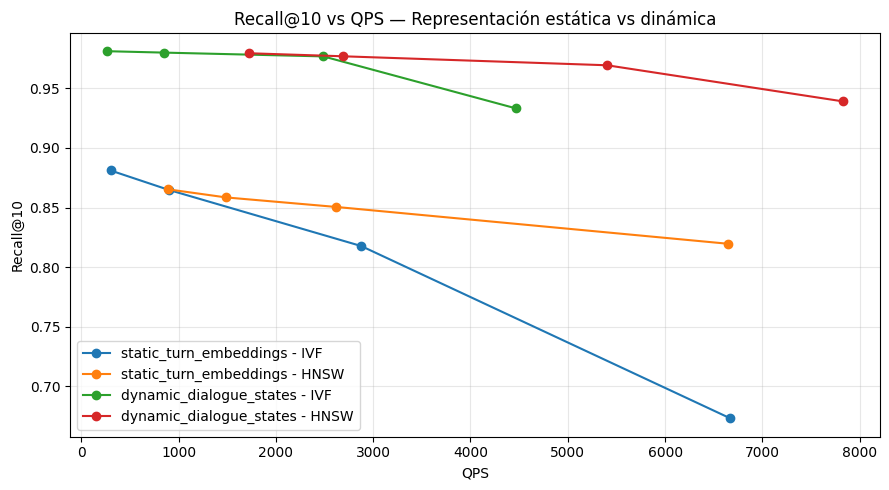

In [27]:
plt.figure(figsize=(9, 5))

for representation in df_results["representation"].unique():
    for index_type in ["IVF", "HNSW"]:
        subset = df_results[
            (df_results["representation"] == representation) &
            (df_results["index_type"] == index_type)
        ].sort_values("qps")

        label = f"{representation} - {index_type}"
        plt.plot(subset["qps"], subset["recall@10"], marker="o", label=label)

plt.xlabel("QPS")
plt.ylabel("Recall@10")
plt.title("Recall@10 vs QPS — Representación estática vs dinámica")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

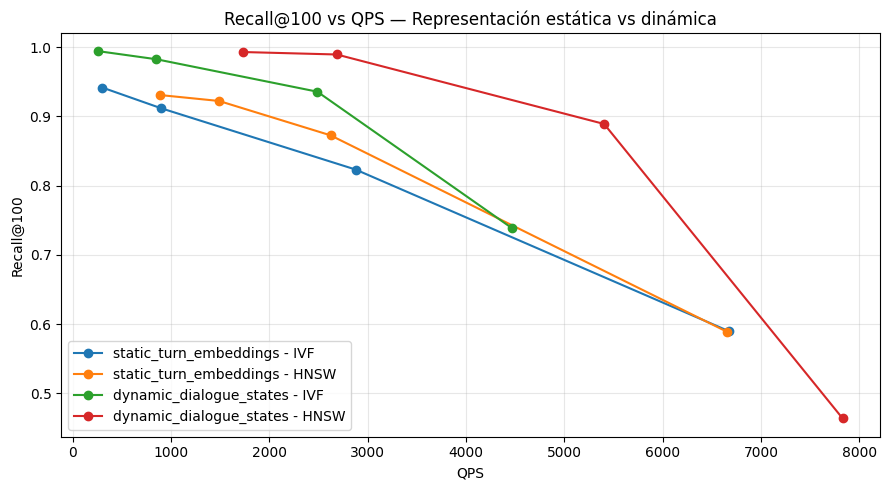

In [28]:
plt.figure(figsize=(9, 5))

for representation in df_results["representation"].unique():
    for index_type in ["IVF", "HNSW"]:
        subset = df_results[
            (df_results["representation"] == representation) &
            (df_results["index_type"] == index_type)
        ].sort_values("qps")

        label = f"{representation} - {index_type}"
        plt.plot(subset["qps"], subset["recall@100"], marker="o", label=label)

plt.xlabel("QPS")
plt.ylabel("Recall@100")
plt.title("Recall@100 vs QPS — Representación estática vs dinámica")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Diagnóstico por parámetro

Estas tablas ayudan a interpretar si los índices se comportan de forma coherente al variar `nprobe` o `efSearch`.

In [29]:
df_results[
    df_results["index_type"] == "IVF"
][
    ["representation", "nprobe", "qps", "recall@10", "recall@100"]
].sort_values(["representation", "nprobe"])

,representation,nprobe,qps,recall@10,recall@100
10,dynamic_dialogue_states,1.0,4470.233642,0.93315,0.738230
11,dynamic_dialogue_states,4.0,2487.680675,0.97686,0.935540
12,dynamic_dialogue_states,16.0,850.857189,0.98004,0.982398
13,dynamic_dialogue_states,64.0,262.253268,0.98123,0.994015
1,static_turn_embeddings,1.0,6671.054335,0.67298,0.589899
2,static_turn_embeddings,4.0,2875.906695,0.81768,0.823208
3,static_turn_embeddings,16.0,899.000095,0.86478,0.911652
4,static_turn_embeddings,64.0,300.008172,0.88111,0.941588


In [30]:
df_results[
    df_results["index_type"] == "HNSW"
][
    ["representation", "efSearch", "qps", "recall@10", "recall@100"]
].sort_values(["representation", "efSearch"])

,representation,efSearch,qps,recall@10,recall@100
14,dynamic_dialogue_states,16.0,7828.619051,0.93909,0.463987
15,dynamic_dialogue_states,64.0,5404.076858,0.96941,0.888951
16,dynamic_dialogue_states,128.0,2685.258697,0.97697,0.989253
17,dynamic_dialogue_states,256.0,1728.456357,0.97949,0.992822
5,static_turn_embeddings,16.0,6649.711185,0.81954,0.589248
6,static_turn_embeddings,64.0,2621.675623,0.85045,0.872580
7,static_turn_embeddings,128.0,1488.583492,0.85846,0.922146
8,static_turn_embeddings,256.0,888.819457,0.86528,0.930698


## 10. Visualización UMAP de representaciones estáticas y dinámicas

En esta sección se proyectan a dos dimensiones, mediante UMAP, una muestra de embeddings estáticos de turno y sus correspondientes estados latentes dinámicos.

El objetivo de esta visualización no es evaluar la calidad de recuperación de los índices ANN, sino observar de manera exploratoria si ambas representaciones ocupan regiones similares del espacio vectorial o si la incorporación del contexto conversacional acumulado modifica la estructura geométrica de las representaciones.

In [32]:
!pip install -q umap-learn

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


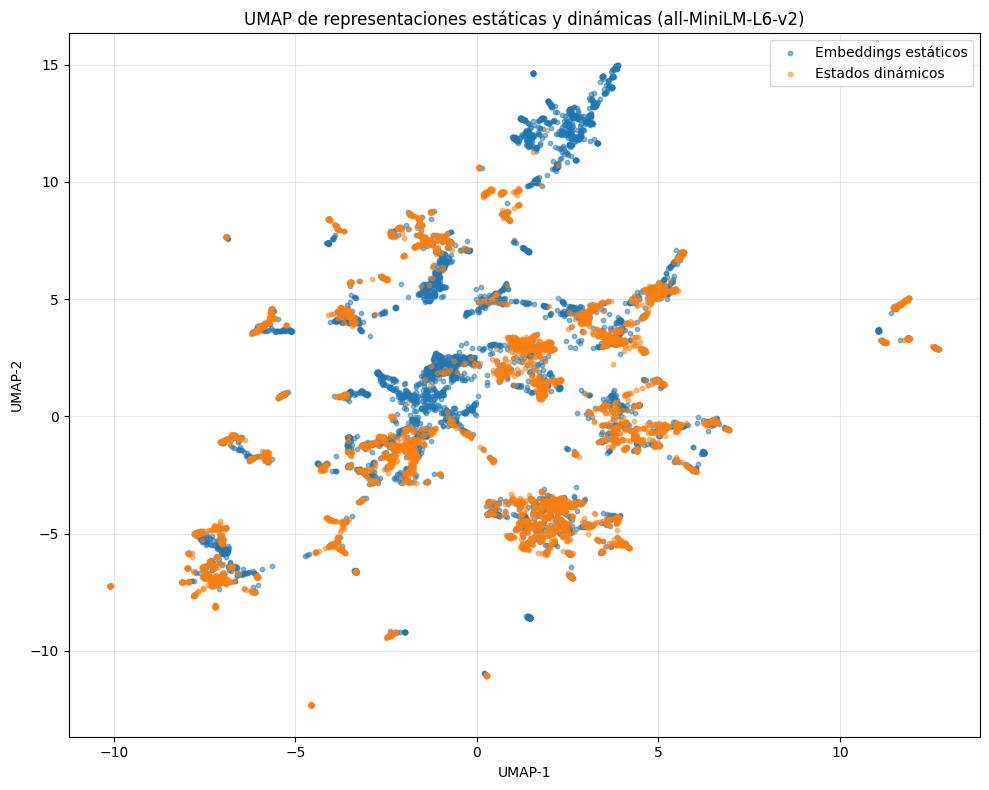

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import umap

# Muestra para UMAP
N_UMAP = 5000
RANDOM_STATE_UMAP = 42

np.random.seed(RANDOM_STATE_UMAP)

umap_idx = np.random.choice(
    np.arange(dynamic_embeddings.shape[0]),
    size=min(N_UMAP, dynamic_embeddings.shape[0]),
    replace=False
)

static_umap = np.asarray(embeddings[umap_idx], dtype="float32")
dynamic_umap = np.asarray(dynamic_embeddings[umap_idx], dtype="float32")

# Unimos ambas representaciones
X_umap = np.vstack([static_umap, dynamic_umap])
labels_umap = np.array(
    ["Embeddings estáticos"] * len(static_umap) +
    ["Estados dinámicos"] * len(dynamic_umap)
)

# Reducimos dimensionalidad
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

coords_umap = reducer.fit_transform(X_umap)

# Máscara
mask_static = labels_umap == "Embeddings estáticos"
mask_dynamic = labels_umap == "Estados dinámicos"

# Gráfico
plt.figure(figsize=(10, 8))
plt.scatter(
    coords_umap[mask_static, 0],
    coords_umap[mask_static, 1],
    s=10,
    alpha=0.5,
    label="Embeddings estáticos"
)
plt.scatter(
    coords_umap[mask_dynamic, 0],
    coords_umap[mask_dynamic, 1],
    s=10,
    alpha=0.5,
    label="Estados dinámicos"
)

plt.title(f"UMAP de representaciones estáticas y dinámicas ({EMBEDDING_EXPERIMENTO})")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Guardado de resultados

Guardamos:

- la matriz de estados dinámicos;
- las similitudes estático-dinámico;
- los resultados del benchmark reducido.

La fecha-hora se guarda usando hora argentina para facilitar la trazabilidad de corridas.

In [31]:
from google.colab import drive
from datetime import datetime
from zoneinfo import ZoneInfo
import shutil

drive.mount("/content/drive")

carpeta_resultados = "/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados"
carpeta_data = "/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/data/version2.0"

os.makedirs(carpeta_resultados, exist_ok=True)
os.makedirs(carpeta_data, exist_ok=True)

fecha_hora_arg = datetime.now(ZoneInfo("America/Argentina/Buenos_Aires")).strftime("%Y%m%d_%H%M%S")

modelo = EMBEDDING_EXPERIMENTO.replace("/", "_").replace("-", "_")

archivo_resultados = f"resultados_dynamic_states_{modelo}_{fecha_hora_arg}_ARG.csv"
ruta_resultados = os.path.join(carpeta_resultados, archivo_resultados)

df_export = df_results.copy()
df_export["params"] = df_export["params"].astype(str)
df_export.to_csv(ruta_resultados, index=False)

print("Resultados guardados en:")
print(ruta_resultados)

# Copiamos los estados dinámicos y las métricas auxiliares a Drive.
for archivo in [archivo_dynamic, archivo_similitud, archivo_turn_pos]:
    shutil.copy(archivo, os.path.join(carpeta_data, archivo))
    print("Copiado:", os.path.join(carpeta_data, archivo))

Mounted at /content/drive
Resultados guardados en:
/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/resultados_dynamic_states_all_MiniLM_L6_v2_20260527_101143_ARG.csv
Copiado: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/data/version2.0/dynamic_embeddings_minilm.npy
Copiado: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/data/version2.0/similitud_static_dynamic_minilm.npy
Copiado: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/data/version2.0/turn_position_minilm.npy
